In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import os

Now, let's define the paths to our dataset and set up some parameters for image processing, such as image dimensions and batch size. The `path` variable already contains the base directory for the dataset, which was downloaded in the previous cell.

In [3]:
# Define dataset paths
base_dir = path # '/kaggle/input/chest-xray-pneumonia'
train_dir = os.path.join(base_dir, 'chest_xray', 'train')
val_dir = os.path.join(base_dir, 'chest_xray', 'val')
test_dir = os.path.join(base_dir, 'chest_xray', 'test')

# Image parameters
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

print(f"Training data path: {train_dir}")
print(f"Validation data path: {val_dir}")
print(f"Test data path: {test_dir}")

Training data path: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validation data path: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Test data path: /kaggle/input/chest-xray-pneumonia/chest_xray/test


Next, we'll create `ImageDataGenerator` instances for our training, validation, and test sets. We'll apply data augmentation to the training set to help the model generalize better and prevent overfitting. This includes rescaling pixel values, shearing, zooming, and horizontal flipping. The validation and test sets will only be rescaled.

In [4]:
# Data Augmentation for Training data
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    shear_range=0.2, # Apply shear transformations
    zoom_range=0.2, # Apply zoom transformations
    horizontal_flip=True # Flip images horizontally
)

# Rescale for Validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Rescale for Test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' because we have two classes (PNEUMONIA, NORMAL)
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Let's visualize a few augmented training images to see what our model will be trained on.

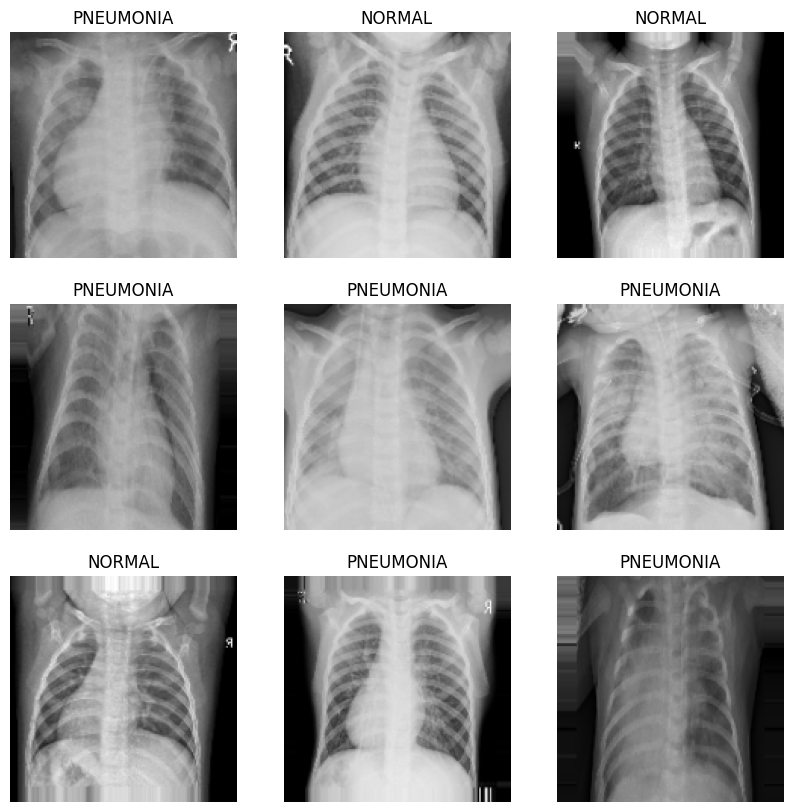

Class labels: ['NORMAL', 'PNEUMONIA']


In [5]:
def plot_images(images, labels):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        if labels[i] == 0:
            plt.title('NORMAL')
        else:
            plt.title('PNEUMONIA')
        plt.axis('off')
    plt.show()

# Get a batch of training images and labels
images, labels = next(train_generator)
plot_images(images, labels)

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())
print("Class labels:", class_names)

For the model, we'll use a sequential CNN. It will consist of several convolutional layers (`Conv2D`) followed by activation functions (ReLU), pooling layers (`MaxPooling2D`) to reduce dimensionality, and dropout layers (`Dropout`) to prevent overfitting. Finally, we'll flatten the output and feed it into a dense layer with a sigmoid activation for binary classification.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dropout(0.5), # Add dropout for regularization
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Now, let's train our model. We'll use the `fit` method, providing our `train_generator` for training data and `validation_generator` for validation data. We'll also define the number of epochs (how many times the model will see the entire dataset) and the number of steps per epoch for both training and validation.

In [7]:
epochs = 10 # You can increase this for better performance

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.7281 - loss: 0.5581 - val_accuracy: 0.5000 - val_loss: 0.6011
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.8528 - loss: 0.3269 - val_accuracy: 0.6250 - val_loss: 1.0979
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8961 - loss: 0.3095 - val_accuracy: 0.6875 - val_loss: 0.7801
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9116 - loss: 0.2783 - val_accuracy: 0.7500 - val_loss: 0.6625
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9210 - loss: 0.2574 - val_accuracy: 0.6875 - val_loss: 0.7430
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9183 - loss: 0.2530 - val_accuracy: 0.6875 - val_loss: 0.6860
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9231 - loss: 0.2419 - val_accuracy: 0.6250 - val_loss: 0.6482
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.9321 - loss: 0.2185 - val_accu

After training, it's good practice to visualize the training history (accuracy and loss over epochs) to check for overfitting or underfitting.

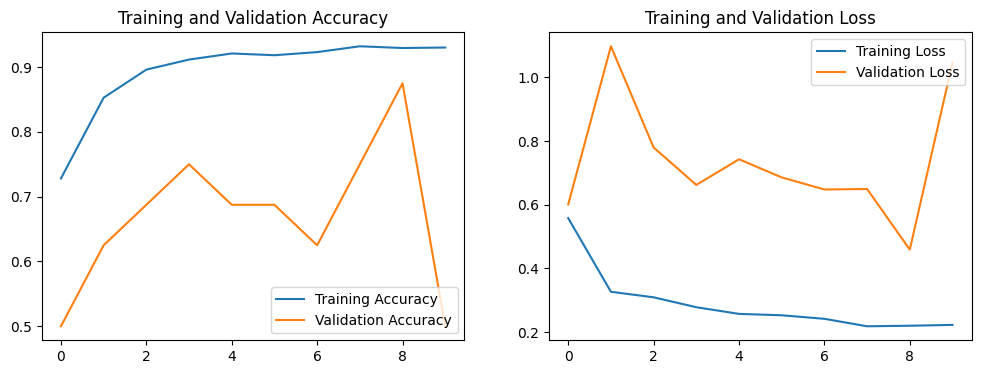

In [8]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

Now we will evaluate the trained model on the test dataset. This will give us an indication of how well the model generalizes to new, unseen images.

In [9]:
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating model on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 711ms/step - accuracy: 0.7596 - loss: 0.7161
Test Loss: 0.7161
Test Accuracy: 0.7596


To get a more detailed understanding of the model's performance, especially for classification tasks, it's beneficial to look at metrics like precision, recall, F1-score, and a confusion matrix. Let's predict the classes for the test dataset and compute these metrics.

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.36      0.53       234
   PNEUMONIA       0.72      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.68      0.68       624
weighted avg       0.83      0.76      0.72       624



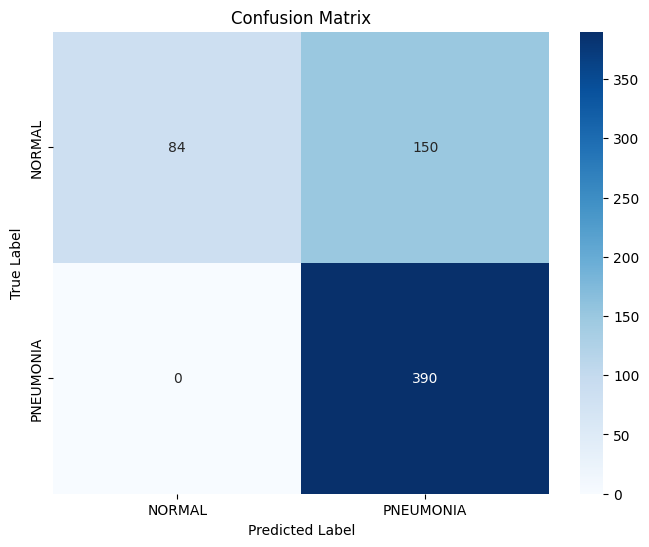

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on the test set
# Reset the test generator to ensure predictions are in order
test_generator.reset()
predictions = model.predict(test_generator)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int)

# Get true labels
y_true = test_generator.classes

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [11]:
from IPython.display import display, Image
from ipywidgets import FileUpload, Output
from PIL import Image
import io

Now, let's create the upload widget. After you upload an image, a function will process it and display the prediction.

In [16]:
uploader = FileUpload(accept='image/*', multiple=False)
output = Output()

def predict_uploaded_image(change):
    with output:
        display(clear_output=True)
        try:
            uploaded_file = list(uploader.value.values())[0]
            content = uploaded_file['content']

            # Convert bytes to PIL Image
            img = Image.open(io.BytesIO(content))

            # Preprocess the image (resize and normalize)
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            img_array = np.array(img).astype('float32') / 255.0

            # Ensure 3 channels (RGB) even if input is grayscale
            if img_array.ndim == 2: # Grayscale image
                img_array = np.stack((img_array,)*3, axis=-1)
            elif img_array.shape[-1] == 4: # RGBA image
                img_array = img_array[..., :3] # Take only RGB channels

            # Add batch dimension
            img_array = np.expand_dims(img_array, axis=0)

            # Make prediction
            prediction = model.predict(img_array)
            predicted_class_index = (prediction > 0.5).astype(int)[0][0]
            predicted_class_label = class_names[predicted_class_index]

            print(f"Predicted class: {predicted_class_label} (Confidence: {prediction[0][0]:.4f})")
            display(img) # Display the uploaded image

        except Exception as e:
            print(f"Error processing image: {e}")

# Attach the event handler
uploader.observe(predict_uploaded_image, names='value')

display(uploader, output)

FileUpload(value={}, accept='image/*', description='Upload')

Output()